In [13]:
from Tools import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import scipy.stats

# LaTex Formatierung in Plots
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern"
})

<Axes: xlabel='Länge (m)', ylabel='Wiederstand ($\\Omega$)'>

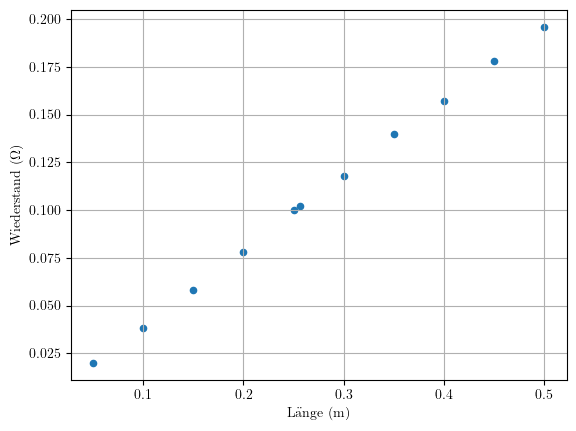

In [14]:
r = 0.25e-3/2 # Radius in m
A = np.pi * r**2 # Querschnittsfläche in m^2

# Laden und Ordnen der Daten
messdaten = pd.read_excel("V44.xlsx", sheet_name="Teil 2")
messdaten = messdaten.drop(columns=["Schaltung 3", "Mesung", "Bereich", "Wiederstand", "spez R"])  # Entferne die Spalten
messdaten.sort_values(by="Länge (m)", inplace=True)  # Sortiere die Daten nach Länge

# Fügt die Spalten für Widerstand und spezifischen Widerstand hinzu
messdaten[r"Wiederstand ($\Omega$)"] = messdaten["U(V)"] / messdaten["I(A)"]  # Berechne den Widerstand
messdaten[r"spez R"] = messdaten[r"Wiederstand ($\Omega$)"] * (A / messdaten["Länge (m)"])  # Berechne den spezifischen Widerstand

messdaten.plot(x=r"Länge (m)", y=r"Wiederstand ($\Omega$)", kind="scatter", legend=True, grid=True)
# print(messdaten)

In [15]:
l = messdaten[r"Länge (m)"].to_numpy()
R = messdaten[r"Wiederstand ($\Omega$)"].to_numpy()

error = np.array([0.001]*len(l))  # Fehler in Ohm

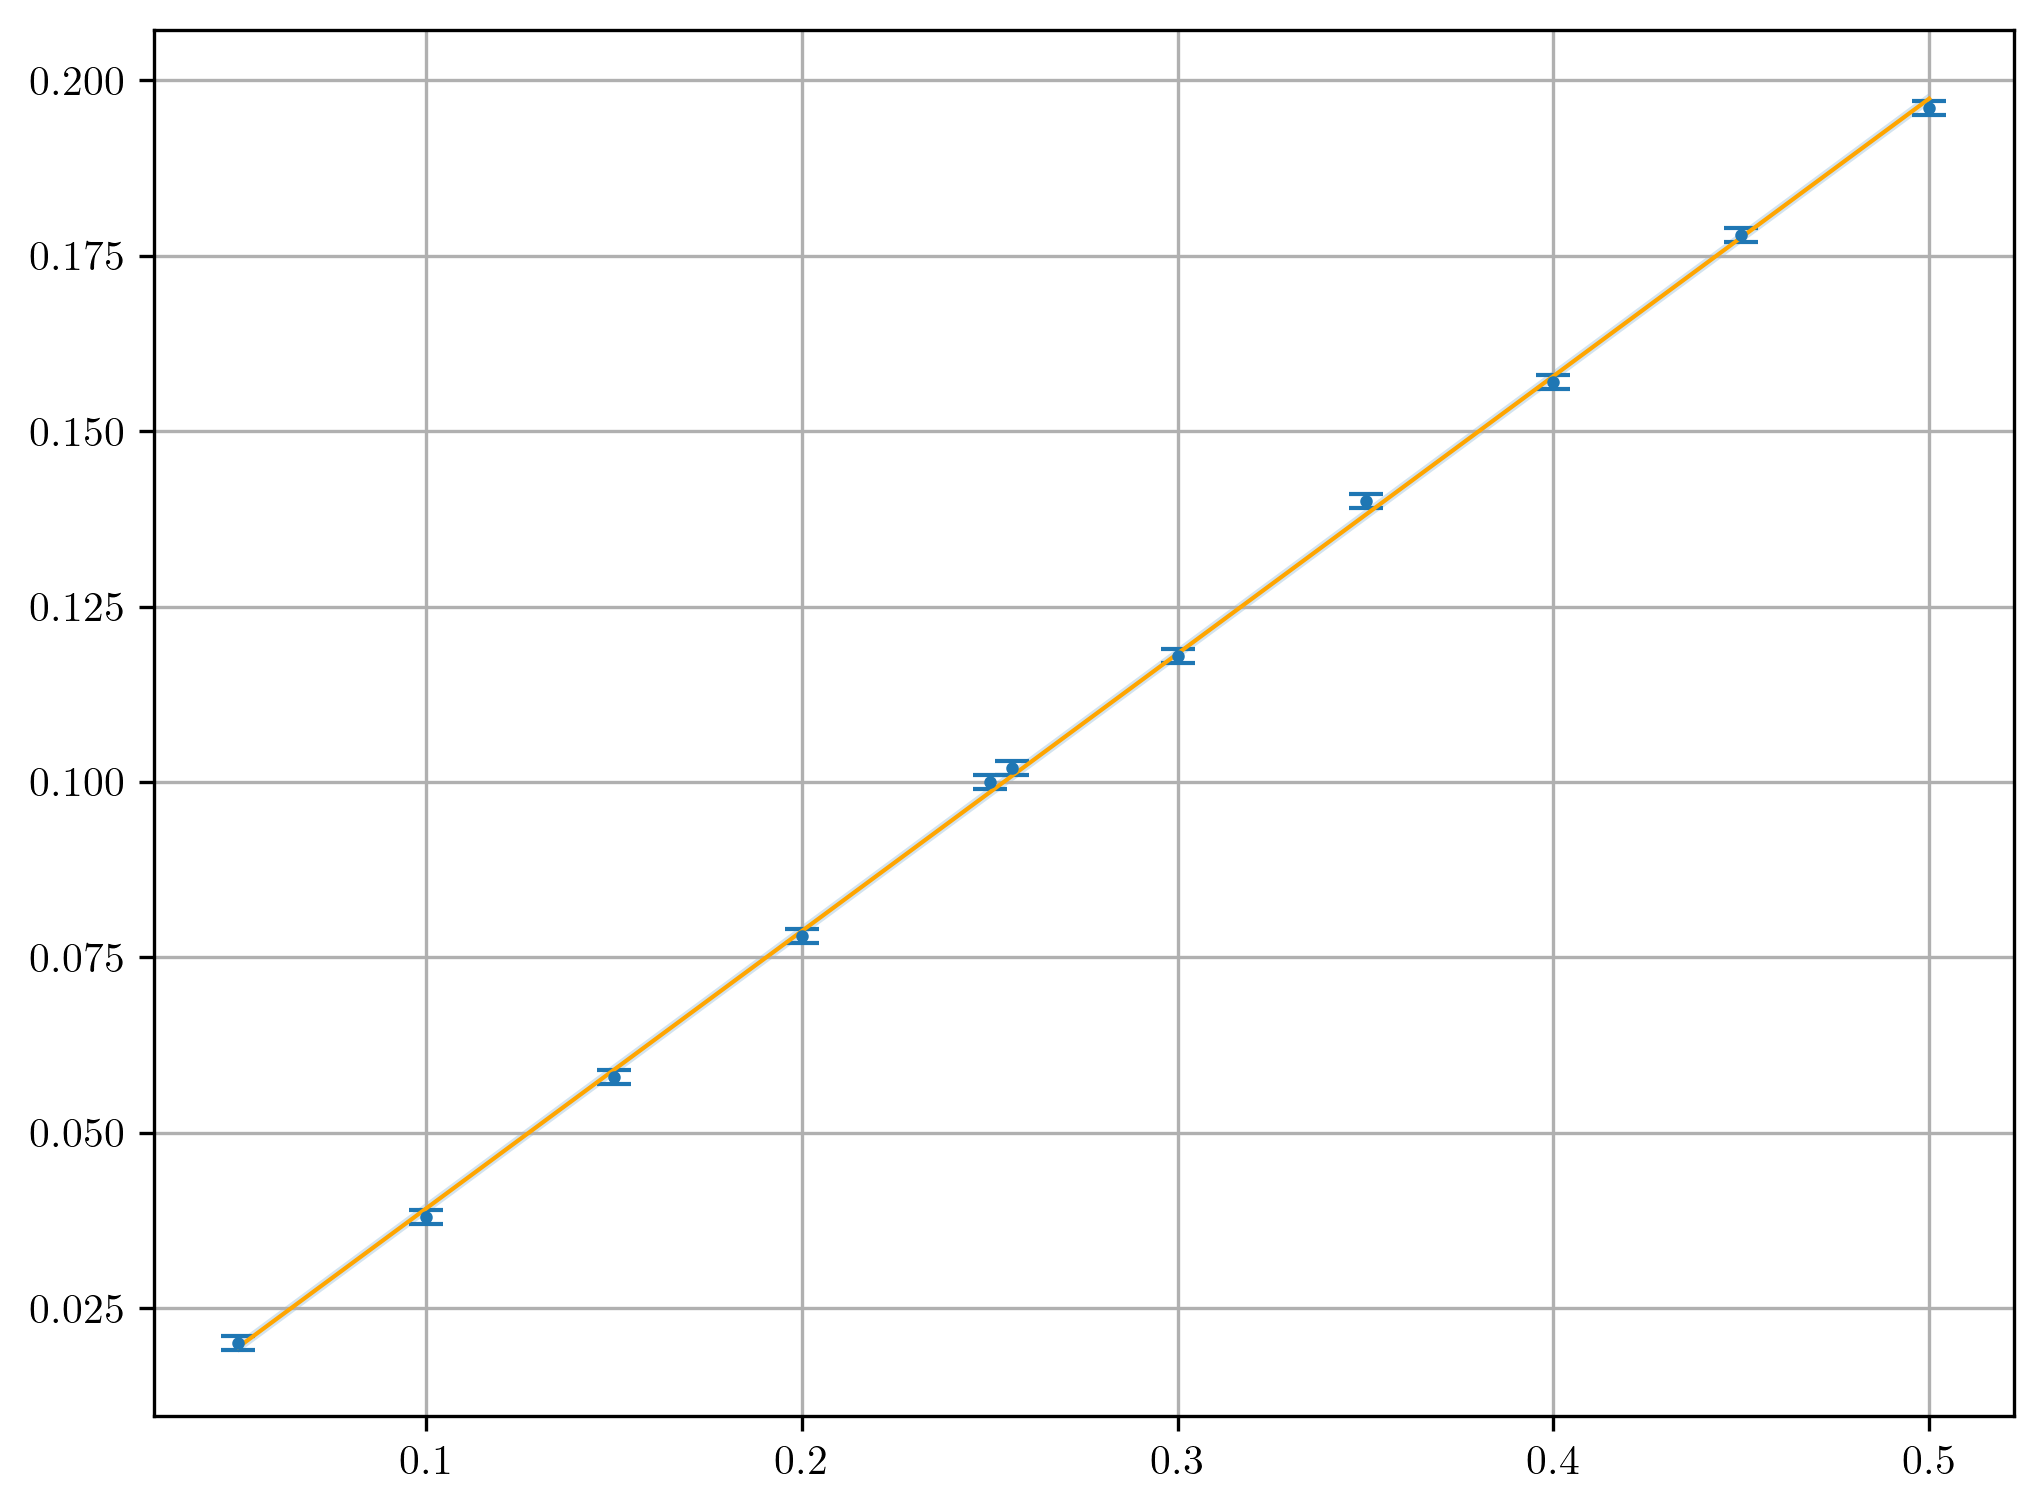

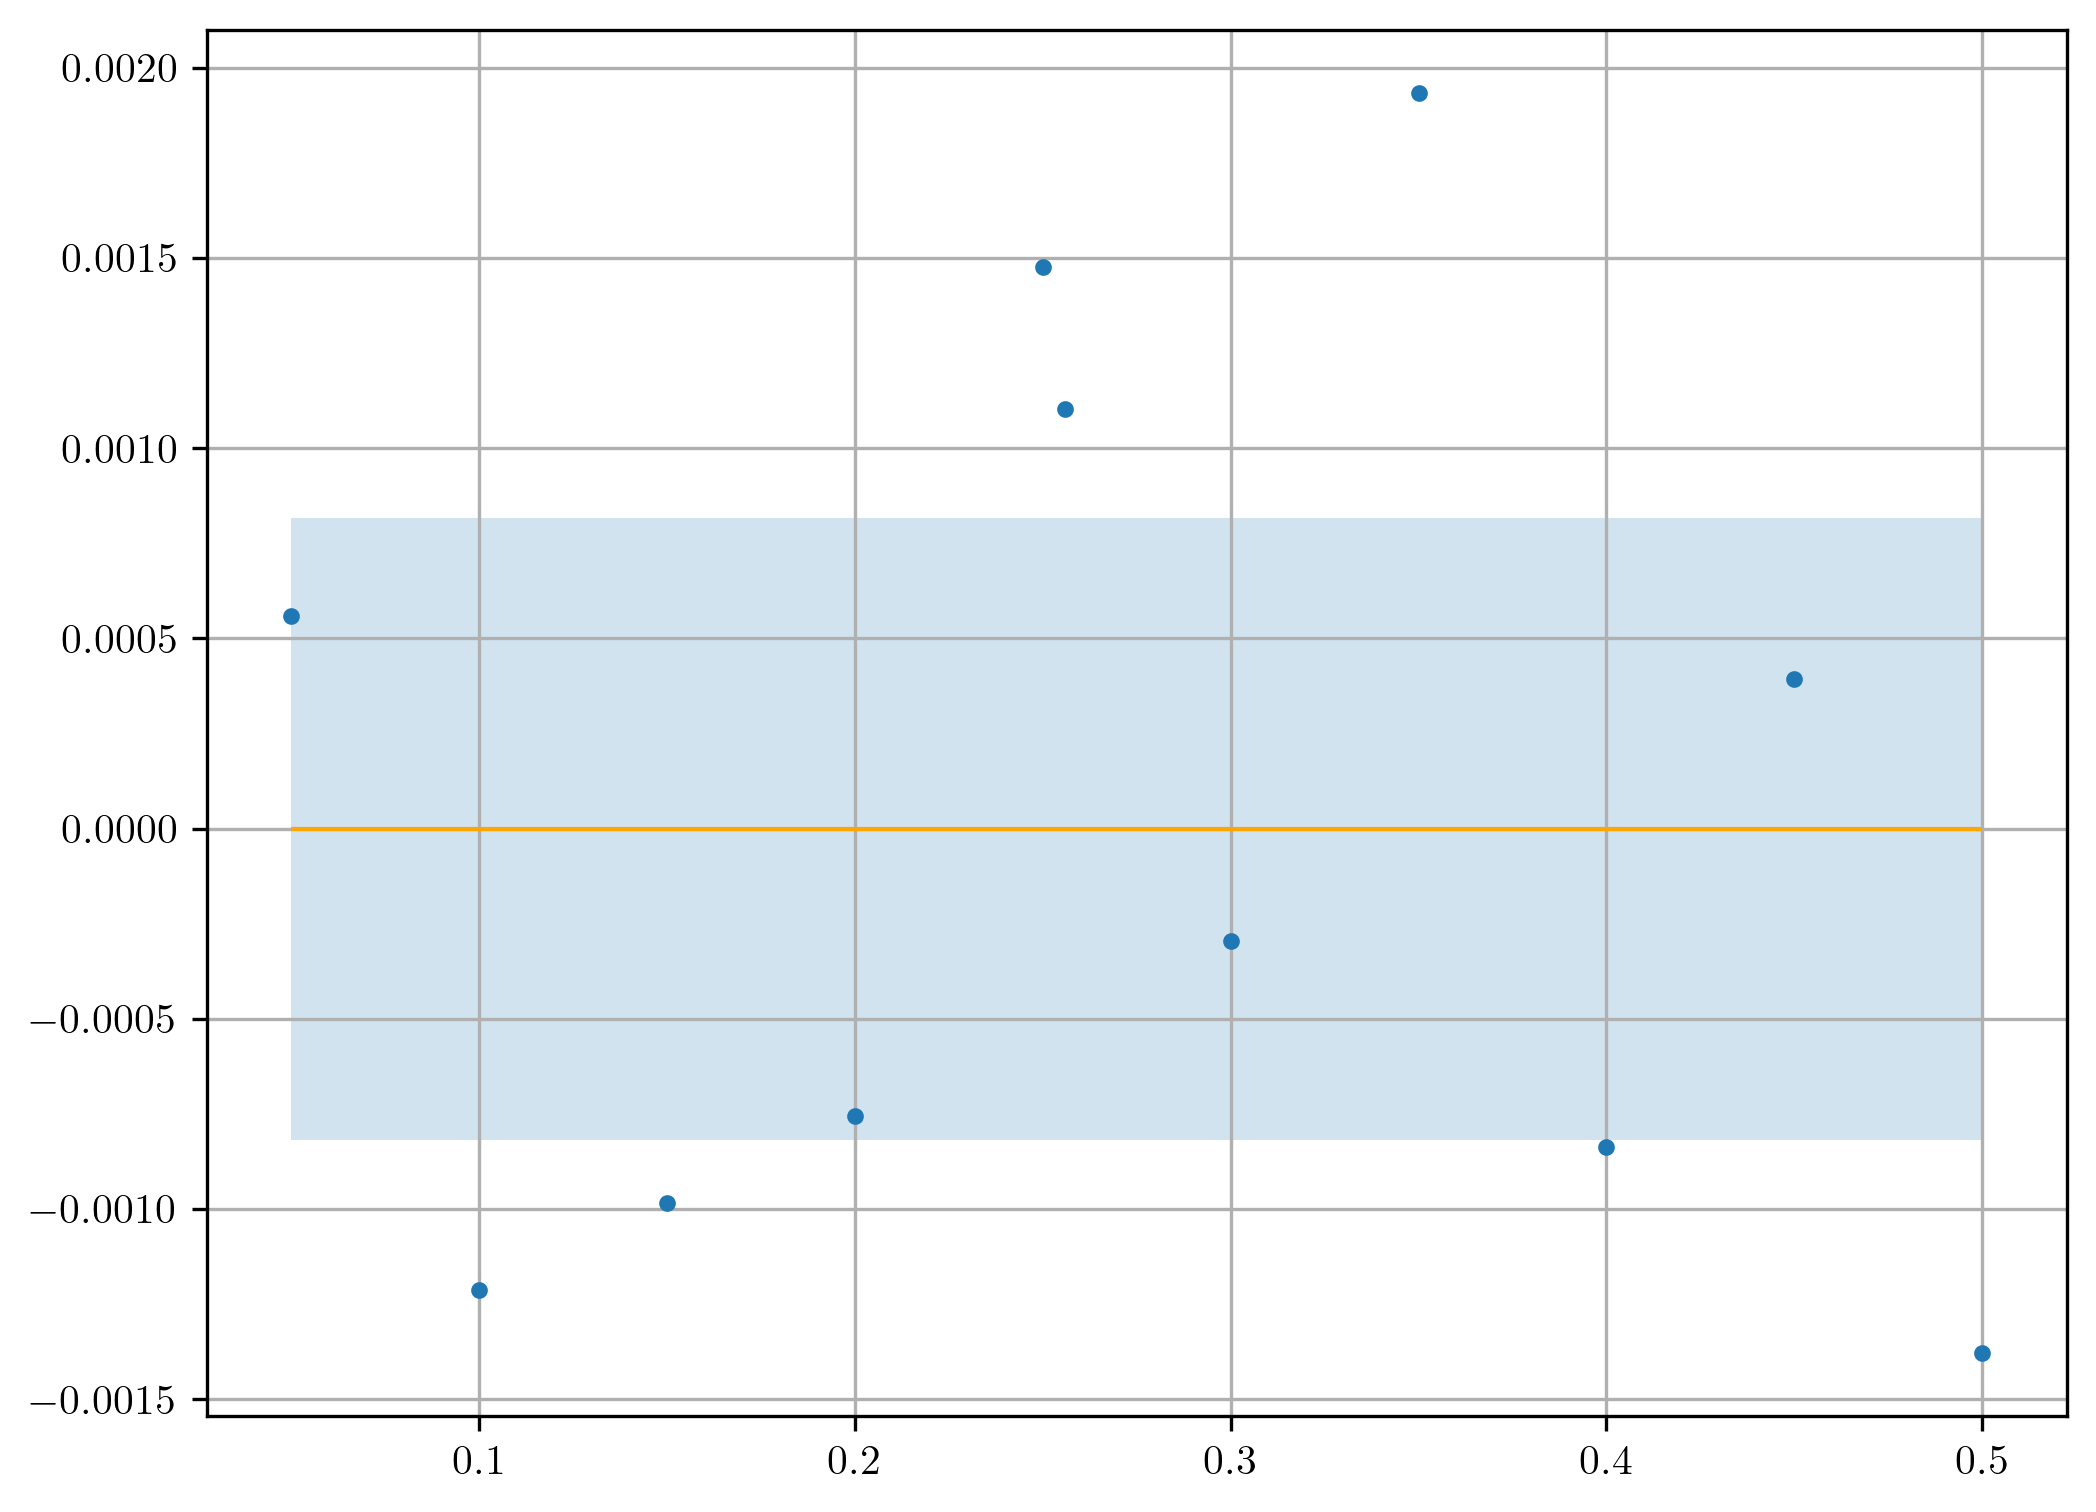

end=> Steigung: 0.3954 ± 0.0027, Achsenabschnitt: -0.0003 ± 0.0008


In [16]:
# simpy test 
linfit = scipy.stats.linregress(l, R)

Residuendiagramm_manuell(l, R, error, linfit.slope, linfit.intercept, linfit.stderr, linfit.intercept_stderr)
print(f"end=> Steigung: {linfit.slope:.4f} ± {linfit.stderr:.4f}, Achsenabschnitt: {linfit.intercept:.4f} ± {linfit.intercept_stderr:.4f}")


In [17]:
# Werte Berechnen

print("Spezifischer Widerstand: ", np.mean(messdaten[r"spez R"]))

Spezifischer Widerstand:  1.9315855091545123e-08


Index(['U(V)', 'I(A)', 'Bereich', 'Länge'], dtype='object')
Index(['U(V)', 'I(A)', 'Bereich', 'Länge'], dtype='object')
Index(['U(V)', 'I(A)', 'Bereich', 'Länge'], dtype='object')
Index(['U(V)', 'I(A)', 'Bereich', 'Länge'], dtype='object')
Index(['U(V)', 'I(A)', 'Bereich', 'Länge'], dtype='object')
Index(['U(V)', 'I(A)', 'Bereich', 'Länge'], dtype='object')


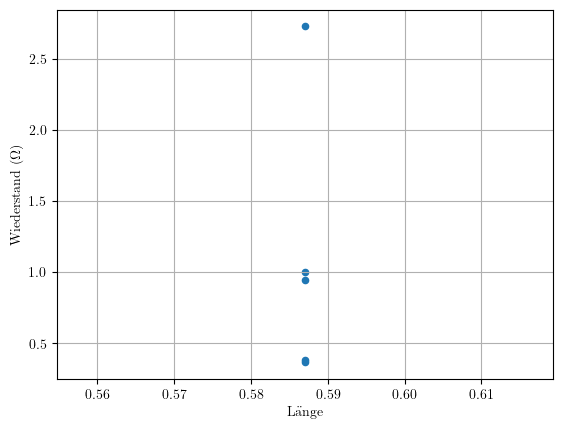

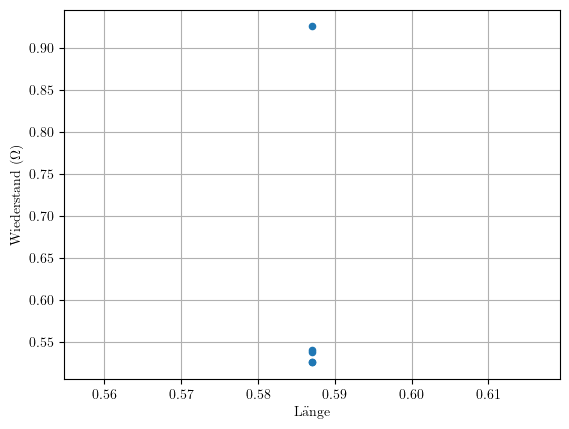

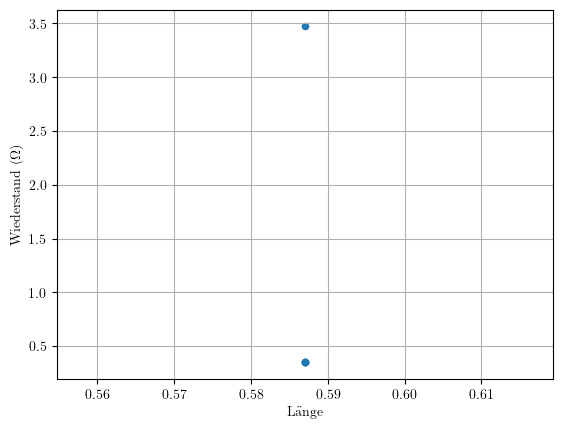

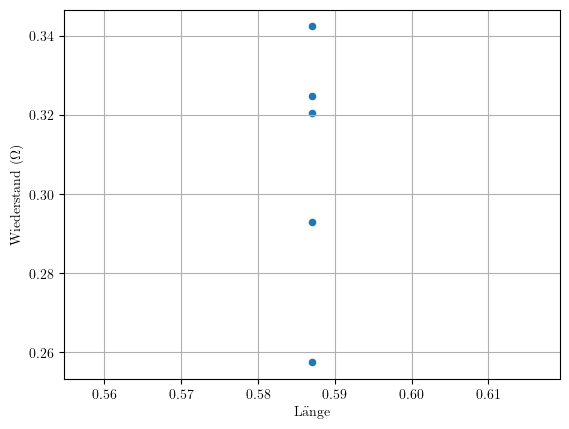

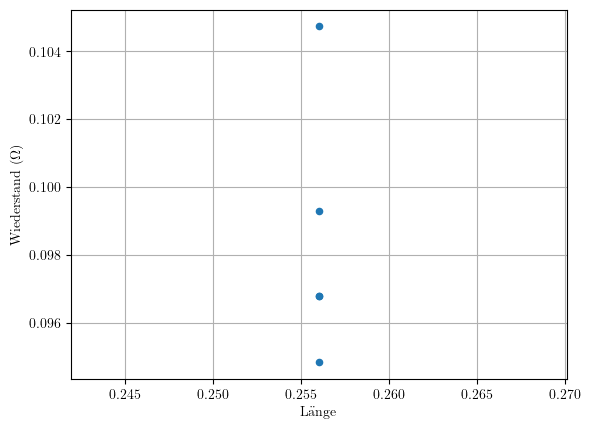

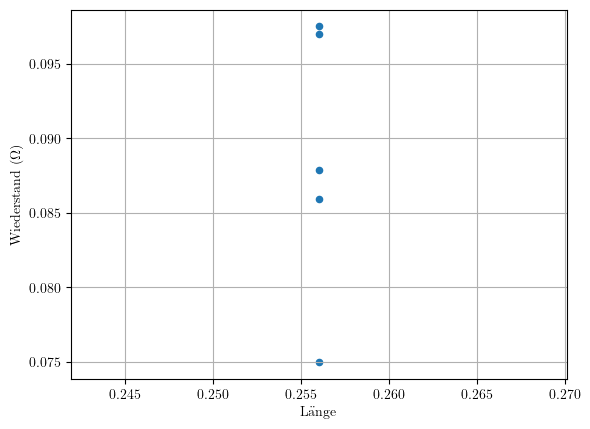

In [ ]:
r = 0.25e-3/2 # Radius in m
A = np.pi * r**2 # Querschnittsfläche in m^2

sheets_Versuch = ["11", "12", "21", "22", "31", "32"]

for sheet in sheets_Versuch:
    Tabelle = pd.read_excel("V44.xlsx", sheet_name=sheet)
    print(Tabelle.columns)
    Tabelle.sort_values(by="U(V)", inplace=True)  # Sortiere die Daten nach Länge
    
    # Fügt die Spalten für Widerstand und spezifischen Widerstand hinzu
    Tabelle[r"Wiederstand ($\Omega$)"] = Tabelle["U(V)"] / Tabelle["I(A)"]  # Berechne den Widerstand
    Tabelle[r"spez R"] = Tabelle[r"Wiederstand ($\Omega$)"] * (A / Tabelle["Länge"])  # Berechne den spezifischen Widerstand

    # Fehler Berechnung
    if sheet in ["11", "21", "31"]:
        Tabelle[r"Fehler U"] = 9e-4 + (0.005 * Tabelle["U(V)"]) + 0.001

    else:
    
    Tabelle.plot(x=r"Länge", y=r"Wiederstand ($\Omega$)", kind="scatter", legend=True, grid=True)